# Feature Engineering of Kandy Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("../Kandy_data_cleaned.csv")

In [3]:
df.head(5)

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
0,2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,13.44,550.926096,14.412209,13.008813,27.364692,0.60,15.236582,47.696954
1,2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,15.73,109.000000,12.810000,22.200000,35.010000,1.34,22.206909,61.000000
2,2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,17.42,109.000000,10.900000,19.220000,30.120000,1.56,5.000000,43.000000
3,2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,176.9,13.03,109.000000,11.950000,23.700000,35.660000,1.25,12.000000,42.000000
4,2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,175.2,10.57,290.000000,12.370000,26.980000,39.350000,1.35,23.000000,142.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30066 entries, 0 to 30065
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Period Start Time  30066 non-null  object 
 1   AT                 30066 non-null  float64
 2   RH                 30066 non-null  float64
 3   BP                 30066 non-null  float64
 4   Solar Rad          30066 non-null  float64
 5   Rain Gauge         30066 non-null  float64
 6   WS Raw             30066 non-null  float64
 7   WD Raw             30066 non-null  float64
 8   O3 Conc            30066 non-null  float64
 9   CO Conc            30066 non-null  float64
 10  NO Conc            30066 non-null  float64
 11  NO2 Conc           30066 non-null  float64
 12  NOx Conc           30066 non-null  float64
 13  SO2 Conc           30066 non-null  float64
 14  PM2.5 Conc         30066 non-null  float64
 15  PM10 Conc          30066 non-null  float64
dtypes: float64(15), object

## Convert Period Start Time in to datetime data type

In [5]:
# Trim whitespace and remove CR/LF
s = df['Period Start Time'].astype(str).str.strip().str.replace(r'[\r\n]', '', regex=True)

In [6]:
# Keeps the fractional seconds if non-zero by capturing optional fractional part.
s = s.str.replace(r'\.(\d{1,6})$', r'.\1', regex=True)

In [7]:
# Explicitly remove all fractional seconds:
s_no_ms = s.str.replace(r'\.\d+$', '', regex=True)

In [8]:
# Parsing with milliseconds format first (handles "YYYY-MM-DD HH:MM:SS.fff")
parsed = pd.to_datetime(s, format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')

In [9]:
# Handle NaT for some rows if the present, try no-ms variant
mask_failed = parsed.isna()
if mask_failed.any():
    parsed.loc[mask_failed] = pd.to_datetime(s_no_ms[mask_failed],
                                             format='%Y-%m-%d %H:%M:%S',
                                             errors='coerce')

In [10]:
df['Period Start Time'] = parsed

In [11]:
bad_idx = df[df['Period Start Time'].isna()].index
bad_idx

Index([], dtype='int64')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30066 entries, 0 to 30065
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Period Start Time  30066 non-null  datetime64[ns]
 1   AT                 30066 non-null  float64       
 2   RH                 30066 non-null  float64       
 3   BP                 30066 non-null  float64       
 4   Solar Rad          30066 non-null  float64       
 5   Rain Gauge         30066 non-null  float64       
 6   WS Raw             30066 non-null  float64       
 7   WD Raw             30066 non-null  float64       
 8   O3 Conc            30066 non-null  float64       
 9   CO Conc            30066 non-null  float64       
 10  NO Conc            30066 non-null  float64       
 11  NO2 Conc           30066 non-null  float64       
 12  NOx Conc           30066 non-null  float64       
 13  SO2 Conc           30066 non-null  float64       
 14  PM2.5 

## Adding time column for the future usage

Add hour, day_of_week, month, day_of_year column to use for the new features that going to add

In [13]:
df['hour'] = df['Period Start Time'].dt.hour
df['day_of_week'] = df['Period Start Time'].dt.dayofweek 
df['month'] = df['Period Start Time'].dt.month
df['day_of_year'] = df['Period Start Time'].dt.dayofyear

Add a is_weekend column. Air pollution can be change in the weekend beacuse in Sri Lanka usualy weekend most of the jobs are have leaves and schools are closed during this period. This reduse the traffic and other human activites. This is_weekend feature can have significat impact on the predictions.

In [14]:
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [15]:
df.head(5)

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,...,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc,hour,day_of_week,month,day_of_year,is_weekend
0,2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,13.44,550.926096,...,13.008813,27.364692,0.60,15.236582,47.696954,15,3,1,3,0
1,2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,15.73,109.000000,...,22.200000,35.010000,1.34,22.206909,61.000000,16,3,1,3,0
2,2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,17.42,109.000000,...,19.220000,30.120000,1.56,5.000000,43.000000,17,3,1,3,0
3,2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,176.9,13.03,109.000000,...,23.700000,35.660000,1.25,12.000000,42.000000,18,3,1,3,0
4,2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,175.2,10.57,290.000000,...,26.980000,39.350000,1.35,23.000000,142.000000,19,3,1,3,0


## Adding new features

### Sin and Cos features

By adding this sin and cos features allows to models to understand the smooth transition from 11 PM back to midnight, which is crucial for capturing the daily (diurnal) patterns in pollution and weather data.

In [16]:
df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)

Same here but for the years

In [17]:
df['sin_day_of_year'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['cos_day_of_year'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

In [18]:
df.head(5)

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,...,PM10 Conc,hour,day_of_week,month,day_of_year,is_weekend,sin_hour,cos_hour,sin_day_of_year,cos_day_of_year
0,2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,13.44,550.926096,...,47.696954,15,3,1,3,0,-0.707107,-7.071068e-01,0.05162,0.998667
1,2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,15.73,109.000000,...,61.000000,16,3,1,3,0,-0.866025,-5.000000e-01,0.05162,0.998667
2,2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,17.42,109.000000,...,43.000000,17,3,1,3,0,-0.965926,-2.588190e-01,0.05162,0.998667
3,2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,176.9,13.03,109.000000,...,42.000000,18,3,1,3,0,-1.000000,-1.836970e-16,0.05162,0.998667
4,2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,175.2,10.57,290.000000,...,142.000000,19,3,1,3,0,-0.965926,2.588190e-01,0.05162,0.998667


### Monesoon Cycle feature

Sri Lanka mainly have 4 monesoon cycles. These are unique to Sri Lanka. Major ones are Yala (Northeast) and Maha (Southwest) other 2 cycles lies between this 2 periods.
<br>
<br>
Based on known SL monsoon cycles:
* NE Monsoon (Dec–Feb)
* First Inter-monsoon (Mar–Apr)
* SW Monsoon (May–Sep)
* Second Inter-monsoon (Oct–Nov)
<br>These cycles can have a main impact on air poluttions. Theses adds seasonal climate context pollutant behavior differs sharply between monsoon phases.

In [19]:
def assign_monsoon(month):
    if month in [12,1,2]:
        return "Northeast Monsoon"
    elif month in [3,4]:
        return "First Inter-monsoon"
    elif month in [5,6,7,8,9]:
        return "Southwest Monsoon"
    else:
        return "Second Inter-monsoon"

df['monsoon_phase'] = df['month'].apply(assign_monsoon)

In [20]:
df.head(5)

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,...,hour,day_of_week,month,day_of_year,is_weekend,sin_hour,cos_hour,sin_day_of_year,cos_day_of_year,monsoon_phase
0,2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,13.44,550.926096,...,15,3,1,3,0,-0.707107,-7.071068e-01,0.05162,0.998667,Northeast Monsoon
1,2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,15.73,109.000000,...,16,3,1,3,0,-0.866025,-5.000000e-01,0.05162,0.998667,Northeast Monsoon
2,2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,17.42,109.000000,...,17,3,1,3,0,-0.965926,-2.588190e-01,0.05162,0.998667,Northeast Monsoon
3,2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,176.9,13.03,109.000000,...,18,3,1,3,0,-1.000000,-1.836970e-16,0.05162,0.998667,Northeast Monsoon
4,2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,175.2,10.57,290.000000,...,19,3,1,3,0,-0.965926,2.588190e-01,0.05162,0.998667,Northeast Monsoon


### Holiday feature

Adding a is_holiday column. Air pollution can be change in the holiday beacuse in Sri Lanka usualy holiday most of the jobs are have leaves and schools are closed during this period. This reduse the traffic and other human activites. This is_holiday feature can have significat impact on the predictions.

Getting the holidays using the holiday library

In [21]:
import holidays

sl_holidays = holidays.SriLanka(years=range(2019, 2025))

for date, name in list(sl_holidays.items())[:10]:
    print(date, name)

2019-01-15 දෙමළ තෛපොංැලල් දිනය
2019-02-04 නිදහස් සමරු දිනය
2019-04-14 සිංහල හා දෙමළ අලුත් අවුරුදු දිනය
2019-04-13 සිංහල හා දෙමළ අලුත් අවුරුදු දිනට පෙර දිනය
2019-04-19 බක් පුර පසළොස්වක පෝය දිනය; මහ සිකුරාදා දිනය
2019-05-01 ලොක කම්කරු දිනය
2019-12-25 නත්තල් උත්සව දිනය
2019-03-04 මහ සිවරාත්රි දිනය
2019-10-27 දීපවාලි උත්සව දිනය
2019-01-20 දුරුතු පුර පසළොස්වක පෝය දිනය


In [22]:
df['is_holiday'] = df['Period Start Time'].dt.date.isin(sl_holidays)

In [23]:
df.head(5)

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,...,day_of_week,month,day_of_year,is_weekend,sin_hour,cos_hour,sin_day_of_year,cos_day_of_year,monsoon_phase,is_holiday
0,2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,13.44,550.926096,...,3,1,3,0,-0.707107,-7.071068e-01,0.05162,0.998667,Northeast Monsoon,False
1,2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,15.73,109.000000,...,3,1,3,0,-0.866025,-5.000000e-01,0.05162,0.998667,Northeast Monsoon,False
2,2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,17.42,109.000000,...,3,1,3,0,-0.965926,-2.588190e-01,0.05162,0.998667,Northeast Monsoon,False
3,2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,176.9,13.03,109.000000,...,3,1,3,0,-1.000000,-1.836970e-16,0.05162,0.998667,Northeast Monsoon,False
4,2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,175.2,10.57,290.000000,...,3,1,3,0,-0.965926,2.588190e-01,0.05162,0.998667,Northeast Monsoon,False


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30066 entries, 0 to 30065
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Period Start Time  30066 non-null  datetime64[ns]
 1   AT                 30066 non-null  float64       
 2   RH                 30066 non-null  float64       
 3   BP                 30066 non-null  float64       
 4   Solar Rad          30066 non-null  float64       
 5   Rain Gauge         30066 non-null  float64       
 6   WS Raw             30066 non-null  float64       
 7   WD Raw             30066 non-null  float64       
 8   O3 Conc            30066 non-null  float64       
 9   CO Conc            30066 non-null  float64       
 10  NO Conc            30066 non-null  float64       
 11  NO2 Conc           30066 non-null  float64       
 12  NOx Conc           30066 non-null  float64       
 13  SO2 Conc           30066 non-null  float64       
 14  PM2.5 

### Traffic Hour feature

Adding a traffic_hour column. Air pollution can be changed during the traffic hours because in Sri Lanka most of the traffic happens during the hours of 7 am-10 am and 5 am-20 am. In this time period traffic can have a significant impact on the air quality.

In [25]:
df['traffic_hour'] = df['hour'].isin(range(7,10)) | df['hour'].isin(range(17,20))
df['traffic_hour'] = df['traffic_hour'].astype(int)

In [26]:
df.head(5)

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,...,month,day_of_year,is_weekend,sin_hour,cos_hour,sin_day_of_year,cos_day_of_year,monsoon_phase,is_holiday,traffic_hour
0,2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,13.44,550.926096,...,1,3,0,-0.707107,-7.071068e-01,0.05162,0.998667,Northeast Monsoon,False,0
1,2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,15.73,109.000000,...,1,3,0,-0.866025,-5.000000e-01,0.05162,0.998667,Northeast Monsoon,False,0
2,2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,17.42,109.000000,...,1,3,0,-0.965926,-2.588190e-01,0.05162,0.998667,Northeast Monsoon,False,1
3,2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,176.9,13.03,109.000000,...,1,3,0,-1.000000,-1.836970e-16,0.05162,0.998667,Northeast Monsoon,False,1
4,2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,175.2,10.57,290.000000,...,1,3,0,-0.965926,2.588190e-01,0.05162,0.998667,Northeast Monsoon,False,1


In [27]:
df['traffic_hour'].value_counts()

traffic_hour
0    22546
1     7520
Name: count, dtype: int64

### Traffic Stagnation

In [28]:
df['Traffic_Stagnation'] = df['traffic_hour'] * df['BP']

In [29]:
df.head(5)

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,...,day_of_year,is_weekend,sin_hour,cos_hour,sin_day_of_year,cos_day_of_year,monsoon_phase,is_holiday,traffic_hour,Traffic_Stagnation
0,2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,13.44,550.926096,...,3,0,-0.707107,-7.071068e-01,0.05162,0.998667,Northeast Monsoon,False,0,0.0
1,2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,15.73,109.000000,...,3,0,-0.866025,-5.000000e-01,0.05162,0.998667,Northeast Monsoon,False,0,0.0
2,2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,17.42,109.000000,...,3,0,-0.965926,-2.588190e-01,0.05162,0.998667,Northeast Monsoon,False,1,956.2
3,2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,176.9,13.03,109.000000,...,3,0,-1.000000,-1.836970e-16,0.05162,0.998667,Northeast Monsoon,False,1,956.8
4,2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,175.2,10.57,290.000000,...,3,0,-0.965926,2.588190e-01,0.05162,0.998667,Northeast Monsoon,False,1,957.6


In [30]:
df['Traffic_Stagnation'].value_counts()

Traffic_Stagnation
0.000000      22546
955.100000      161
955.000000      161
954.400000      159
954.900000      154
              ...  
952.205263        1
952.415789        1
952.442105        1
952.468421        1
950.835714        1
Name: count, Length: 478, dtype: int64

### Covid Lockdown feature

Adding a is_covid_lockdown column. During the COVID-19 lockdown durations all the human activities almost come to stop at Sri Lanka. This had a significant impact on the air pollution because there are almost 0 human outdoor activities and traffic happens during that time period.

In [31]:
df['is_covid_lockdown'] = 0

In [32]:
df.loc[(df['Period Start Time'].between('2020-03-20','2020-05-11')), 'is_covid_lockdown'] = 1

In [33]:
df.head(5)

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,...,is_weekend,sin_hour,cos_hour,sin_day_of_year,cos_day_of_year,monsoon_phase,is_holiday,traffic_hour,Traffic_Stagnation,is_covid_lockdown
0,2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,13.44,550.926096,...,0,-0.707107,-7.071068e-01,0.05162,0.998667,Northeast Monsoon,False,0,0.0,0
1,2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,15.73,109.000000,...,0,-0.866025,-5.000000e-01,0.05162,0.998667,Northeast Monsoon,False,0,0.0,0
2,2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,17.42,109.000000,...,0,-0.965926,-2.588190e-01,0.05162,0.998667,Northeast Monsoon,False,1,956.2,0
3,2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,176.9,13.03,109.000000,...,0,-1.000000,-1.836970e-16,0.05162,0.998667,Northeast Monsoon,False,1,956.8,0
4,2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,175.2,10.57,290.000000,...,0,-0.965926,2.588190e-01,0.05162,0.998667,Northeast Monsoon,False,1,957.6,0


In [34]:
df['is_covid_lockdown'].value_counts()

is_covid_lockdown
0    28817
1     1249
Name: count, dtype: int64

### Rolling features

Rolling features give the models crucial context and memory about the recent past. A model doesn't just see the current temperature; it sees what the temperature has been doing.

In [35]:
for col in ['PM2.5 Conc','PM10 Conc', 'NO2 Conc', 'CO Conc']:
    df[f'{col}_lag24'] = df[col].shift(24)          
    df[f'{col}_rolling24_mean'] = df[col].rolling(24).mean()
    df[f'{col}_rolling24_std'] = df[col].rolling(24).std()

In [36]:
for col in ['AT','RH','Solar Rad']:
    df[f'{col}_rolling72_mean'] = df[col].rolling(72).mean()

In [37]:
df.head(5)

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,...,PM10 Conc_rolling24_std,NO2 Conc_lag24,NO2 Conc_rolling24_mean,NO2 Conc_rolling24_std,CO Conc_lag24,CO Conc_rolling24_mean,CO Conc_rolling24_std,AT_rolling72_mean,RH_rolling72_mean,Solar Rad_rolling72_mean
0,2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,13.44,550.926096,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,15.73,109.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,17.42,109.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,176.9,13.03,109.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,175.2,10.57,290.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
df.isnull().sum()

Period Start Time             0
AT                            0
RH                            0
BP                            0
Solar Rad                     0
Rain Gauge                    0
WS Raw                        0
WD Raw                        0
O3 Conc                       0
CO Conc                       0
NO Conc                       0
NO2 Conc                      0
NOx Conc                      0
SO2 Conc                      0
PM2.5 Conc                    0
PM10 Conc                     0
hour                          0
day_of_week                   0
month                         0
day_of_year                   0
is_weekend                    0
sin_hour                      0
cos_hour                      0
sin_day_of_year               0
cos_day_of_year               0
monsoon_phase                 0
is_holiday                    0
traffic_hour                  0
Traffic_Stagnation            0
is_covid_lockdown             0
PM2.5 Conc_lag24             24
PM2.5 Co

In [39]:
df2 = df.bfill().fillna(0)

In [40]:
df2.isnull().sum()

Period Start Time            0
AT                           0
RH                           0
BP                           0
Solar Rad                    0
Rain Gauge                   0
WS Raw                       0
WD Raw                       0
O3 Conc                      0
CO Conc                      0
NO Conc                      0
NO2 Conc                     0
NOx Conc                     0
SO2 Conc                     0
PM2.5 Conc                   0
PM10 Conc                    0
hour                         0
day_of_week                  0
month                        0
day_of_year                  0
is_weekend                   0
sin_hour                     0
cos_hour                     0
sin_day_of_year              0
cos_day_of_year              0
monsoon_phase                0
is_holiday                   0
traffic_hour                 0
Traffic_Stagnation           0
is_covid_lockdown            0
PM2.5 Conc_lag24             0
PM2.5 Conc_rolling24_mean    0
PM2.5 Co

### Wind Feature

In [41]:
df2['WD_sin'] = np.sin(df['WD Raw'] * (2 * np.pi / 360))
df2['WD_cos'] = np.cos(df['WD Raw'] * (2 * np.pi / 360))

In [42]:
df2.drop('WD Raw', axis = 1, inplace= True)

### Heat Humidity feature

In [43]:
df2['Heat_Humidity_Interaction'] = df2['AT'] * df2['RH']

In [44]:
df2.describe()

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,O3 Conc,CO Conc,NO Conc,...,NO2 Conc_rolling24_std,CO Conc_lag24,CO Conc_rolling24_mean,CO Conc_rolling24_std,AT_rolling72_mean,RH_rolling72_mean,Solar Rad_rolling72_mean,WD_sin,WD_cos,Heat_Humidity_Interaction
count,30066,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.00000,30066.000000,30066.000000,...,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000
mean,2021-05-22 06:18:56.944911104,25.913497,71.071717,954.422928,166.091174,0.178251,1.128142,11.42685,634.615977,14.072506,...,6.120106,633.056430,633.605115,200.957686,25.908515,71.060507,166.307969,-0.228418,-0.739778,1800.056862
min,2019-01-03 15:00:00,17.100000,17.220000,924.200000,0.020000,0.000000,0.000000,0.00000,50.157000,0.000000,...,0.000475,50.157000,93.789083,0.107939,22.172222,48.908204,7.291065,-1.000000,-1.000000,604.422000
25%,2019-12-23 21:15:00,23.300000,60.492500,953.100000,0.160000,0.000000,0.400000,5.28000,452.940000,1.870000,...,3.805341,452.980000,534.726875,132.538759,24.861111,66.935486,128.941250,-0.736097,-0.937282,1669.455000
50%,2020-11-01 01:30:00,25.100000,74.350000,954.400000,13.620000,0.000000,1.000000,8.94000,609.541201,9.420000,...,5.413636,609.288032,624.940208,185.552688,25.769444,70.870972,164.220000,-0.366501,-0.826098,1833.733000
75%,2023-02-04 20:45:00,28.307542,82.897500,955.700000,291.860000,0.000000,1.700000,15.43000,758.647500,18.470000,...,8.062971,757.997500,718.595208,238.383746,26.841667,75.794132,199.788229,0.315649,-0.618408,1957.298000
max,2024-12-31 23:00:00,36.600000,95.970000,962.000000,980.190000,57.100000,4.000000,87.80000,9401.800000,258.450000,...,42.289497,9401.800000,3891.936667,2960.038712,31.499265,86.583611,692.829722,0.999998,1.000000,2465.250000
std,NaN,3.357941,14.502207,1.974343,237.047341,1.378443,0.863429,9.27585,325.307788,16.909667,...,3.961355,319.112211,204.105288,156.114883,1.472176,6.384280,61.012578,0.576753,0.260620,237.541250


### Low_Activity_Zone

In [45]:
df2['Low_Activity_Zone'] = ((df2['day_of_week'] == 6) & (df2['hour'].isin([0,1,2,3,4,5]))).astype(int)

In [46]:
df2.head(5)

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,O3 Conc,CO Conc,NO Conc,...,CO Conc_lag24,CO Conc_rolling24_mean,CO Conc_rolling24_std,AT_rolling72_mean,RH_rolling72_mean,Solar Rad_rolling72_mean,WD_sin,WD_cos,Heat_Humidity_Interaction,Low_Activity_Zone
0,2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,13.44,550.926096,14.412209,...,550.926096,278.788587,128.28259,24.236111,66.079028,239.477083,0.557745,-0.830012,1338.035,0
1,2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,15.73,109.000000,12.810000,...,550.926096,278.788587,128.28259,24.236111,66.079028,239.477083,0.528438,-0.848972,1427.420,0
2,2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,17.42,109.000000,10.900000,...,550.926096,278.788587,128.28259,24.236111,66.079028,239.477083,0.393942,-0.919135,1510.825,0
3,2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,13.03,109.000000,11.950000,...,550.926096,278.788587,128.28259,24.236111,66.079028,239.477083,0.054079,-0.998537,1553.328,0
4,2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,10.57,290.000000,12.370000,...,550.926096,278.788587,128.28259,24.236111,66.079028,239.477083,0.083678,-0.996493,1630.800,0


## Correlation Check

In [47]:
numeric_df = df2.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

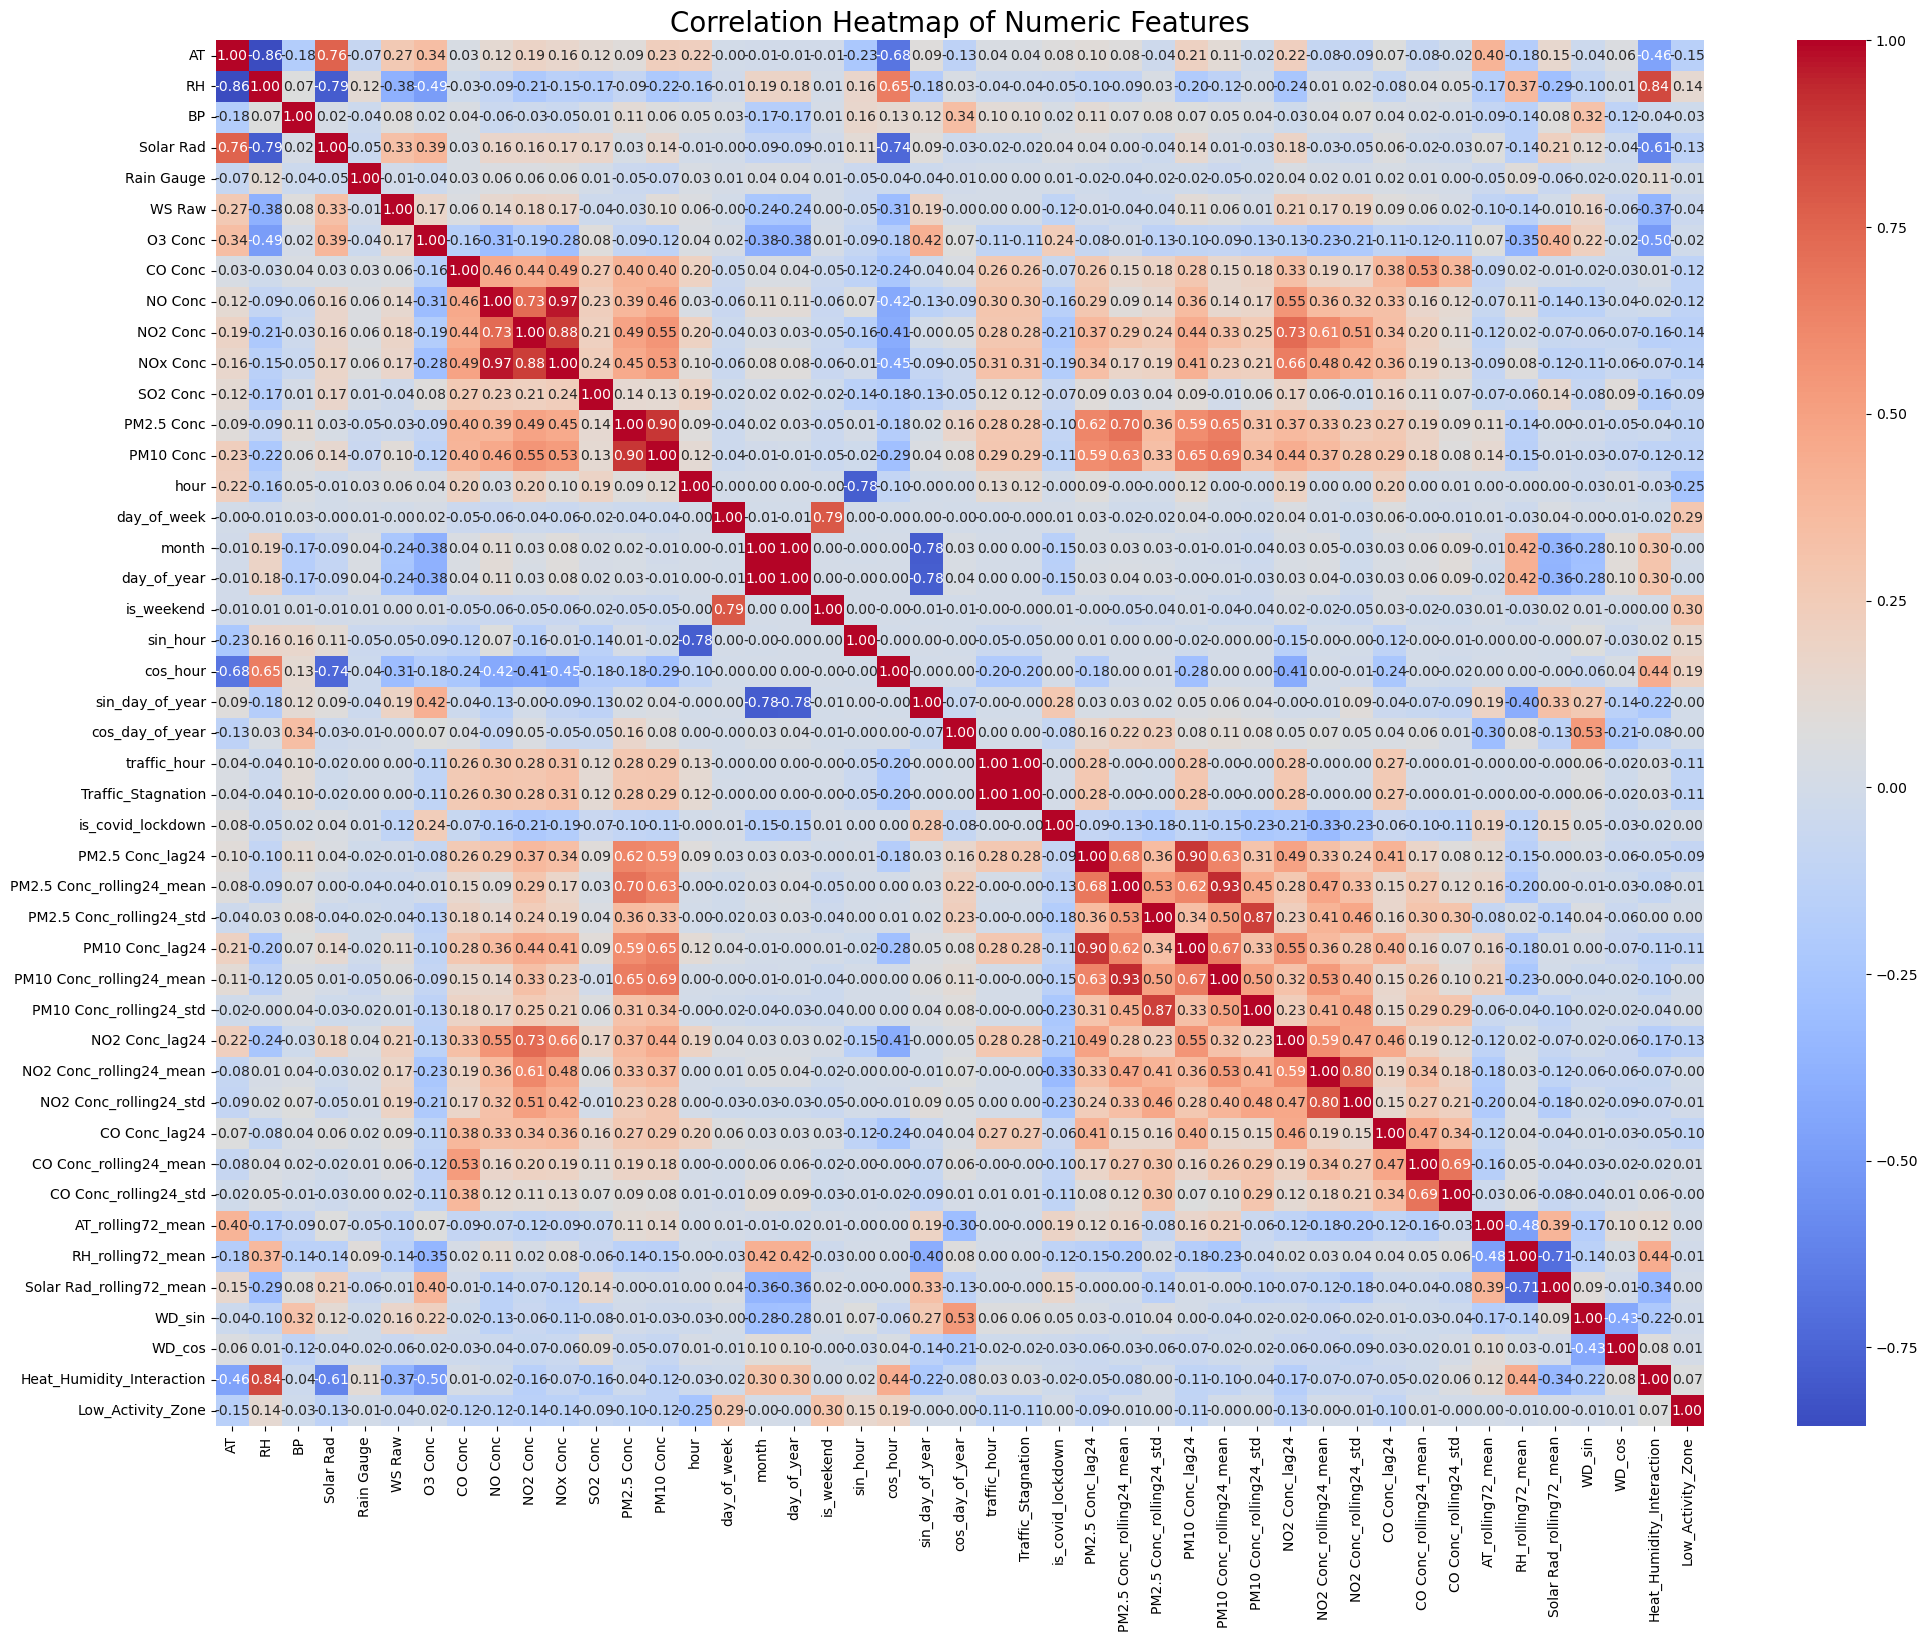

In [48]:
plt.figure(figsize=(24, 18))
sns.heatmap(
    corr_matrix, 
    annot=True,      
    cmap='coolwarm', 
    fmt='.2f'        
)
plt.title('Correlation Heatmap of Numeric Features', fontsize=20)
plt.show()

## Encoding

### One hot encoding

In [49]:
from sklearn.preprocessing import OneHotEncoder

categorical_columns = df2.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df2[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

df_encoded = pd.concat([df2, one_hot_df], axis=1)

df_encoded = df_encoded.drop(categorical_columns, axis=1)

In [50]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30066 entries, 0 to 30065
Data columns (total 51 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Period Start Time                   30066 non-null  datetime64[ns]
 1   AT                                  30066 non-null  float64       
 2   RH                                  30066 non-null  float64       
 3   BP                                  30066 non-null  float64       
 4   Solar Rad                           30066 non-null  float64       
 5   Rain Gauge                          30066 non-null  float64       
 6   WS Raw                              30066 non-null  float64       
 7   O3 Conc                             30066 non-null  float64       
 8   CO Conc                             30066 non-null  float64       
 9   NO Conc                             30066 non-null  float64       
 10  NO2 Conc              

In [51]:
df_encoded.head(5)

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,O3 Conc,CO Conc,NO Conc,...,RH_rolling72_mean,Solar Rad_rolling72_mean,WD_sin,WD_cos,Heat_Humidity_Interaction,Low_Activity_Zone,monsoon_phase_First Inter-monsoon,monsoon_phase_Northeast Monsoon,monsoon_phase_Second Inter-monsoon,monsoon_phase_Southwest Monsoon
0,2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,13.44,550.926096,14.412209,...,66.079028,239.477083,0.557745,-0.830012,1338.035,0,0.0,1.0,0.0,0.0
1,2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,15.73,109.000000,12.810000,...,66.079028,239.477083,0.528438,-0.848972,1427.420,0,0.0,1.0,0.0,0.0
2,2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,17.42,109.000000,10.900000,...,66.079028,239.477083,0.393942,-0.919135,1510.825,0,0.0,1.0,0.0,0.0
3,2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,13.03,109.000000,11.950000,...,66.079028,239.477083,0.054079,-0.998537,1553.328,0,0.0,1.0,0.0,0.0
4,2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,10.57,290.000000,12.370000,...,66.079028,239.477083,0.083678,-0.996493,1630.800,0,0.0,1.0,0.0,0.0


In [52]:
corr_matrix2 = df_encoded.corr()

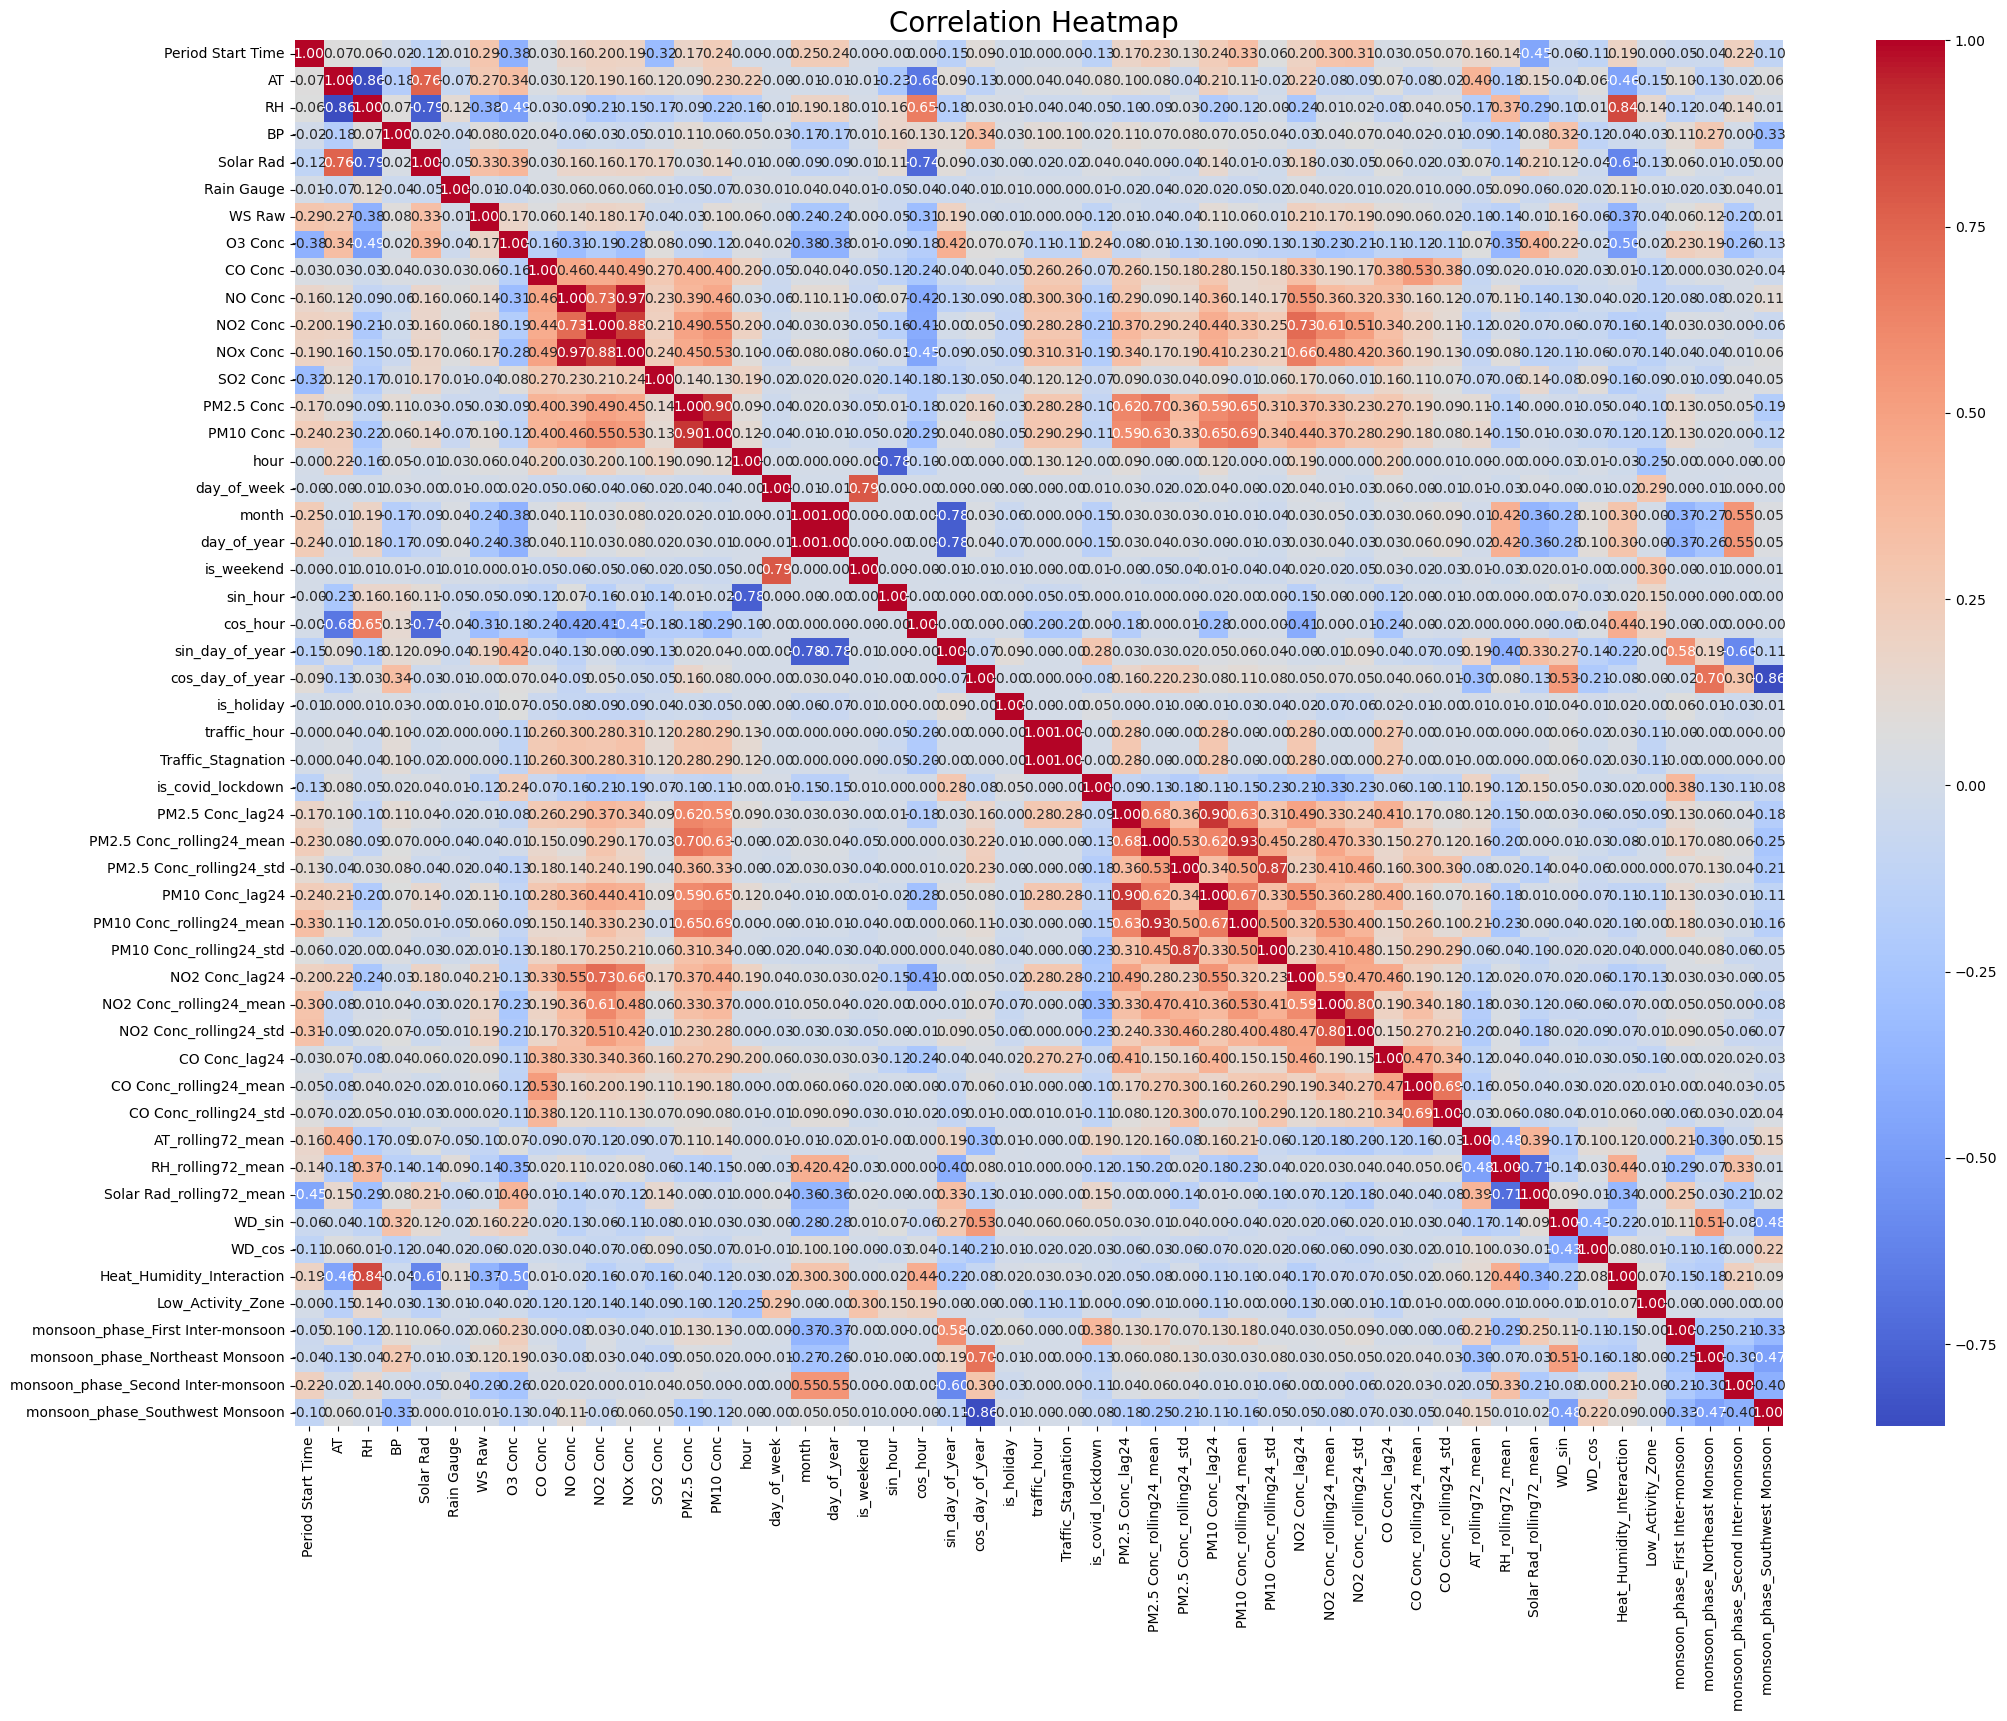

In [53]:
plt.figure(figsize=(24, 18))
sns.heatmap(
    corr_matrix2, 
    annot=True,      
    cmap='coolwarm', 
    fmt='.2f'        
)
plt.title('Correlation Heatmap ', fontsize=20)
plt.show()

## Import as csv file

In [54]:
df_encoded.to_csv("Kandy_data_training.csv", index=False)